# 02 — Model Training & Explainable AI (XAI)

**Objective:** Train four LightGBM classifiers on the NSL-KDD dataset —
1. **Model 0** is a binary Stage 1 filter that predicts *Normal vs. Anomaly*.
2. **Model 1** predicts the *specific* attack type (23+ classes).
3. **Model 2** predicts the *5 main categories* (Normal, DoS, Probe, R2L, U2R).
4. **Model 2.1** is an optimized 5-category variant focused on improving recall for *R2L* and *U2R*.

All models are evaluated with classification reports and confusion matrices.
SHAP (SHapley Additive exPlanations) is used for global interpretability, including the new binary filter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import shap
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("All imports loaded successfully.")

All imports loaded successfully.


/Users/omerahat/Desktop/EXID/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Load Processed Data

Load the feature matrices and target vectors saved by `01_EDA_Feature_Engineering.ipynb`.
The target dataframe (`y`) contains four columns:

| Column | Description |
|---|---|
| `class` | Original attack label (string) |
| `mapped_class` | 5-category label (string) |
| `class_encoded` | Integer-encoded specific attack |
| `mapped_class_encoded` | Integer-encoded 5-category (0–4, or −1 for unseen attacks) |

In [2]:
DATA_DIR = "../data/processed/"

X_train = pd.read_parquet(DATA_DIR + "X_train.parquet")
X_test  = pd.read_parquet(DATA_DIR + "X_test.parquet")
y_train = pd.read_parquet(DATA_DIR + "y_train.parquet")
y_test  = pd.read_parquet(DATA_DIR + "y_test.parquet")

# Drop metadata columns that should not be used as features
cols_to_drop = [c for c in ["difficulty"] if c in X_train.columns]
if cols_to_drop:
    X_train = X_train.drop(columns=cols_to_drop)
    X_test  = X_test.drop(columns=cols_to_drop)
    print(f"Dropped metadata columns: {cols_to_drop}")

# --- Targets for Model 1 (specific attack classes) ---
y_train_specific = y_train["class_encoded"]
y_test_specific  = y_test["class_encoded"]

# --- Targets for Model 2 (5 main categories) ---
# Filter out rows with mapped_class_encoded == -1 (unseen attack types in test)
y_train_mapped = y_train["mapped_class_encoded"]
y_test_mapped  = y_test["mapped_class_encoded"]

train_mask_valid = y_train_mapped != -1
test_mask_valid  = y_test_mapped  != -1

X_train_mapped = X_train[train_mask_valid].reset_index(drop=True)
y_train_mapped = y_train_mapped[train_mask_valid].reset_index(drop=True)

X_test_mapped = X_test[test_mask_valid].reset_index(drop=True)
y_test_mapped = y_test_mapped[test_mask_valid].reset_index(drop=True)

# Category name mapping for display
CATEGORY_NAMES = {0: "Normal", 1: "DoS", 2: "Probe", 3: "R2L", 4: "U2R"}
CATEGORY_LIST  = [CATEGORY_NAMES[i] for i in range(5)]

print(f"X_train:        {X_train.shape}  |  y_train_specific: {y_train_specific.shape}")
print(f"X_test:         {X_test.shape}  |  y_test_specific:  {y_test_specific.shape}")
print(f"X_train_mapped: {X_train_mapped.shape}  |  y_train_mapped:   {y_train_mapped.shape}")
print(f"X_test_mapped:  {X_test_mapped.shape}  |  y_test_mapped:    {y_test_mapped.shape}")
print(f"\nFiltered out {(~test_mask_valid).sum()} test rows with unknown category (mapped_class_encoded == -1)")

Dropped metadata columns: ['difficulty']
X_train:        (125972, 109)  |  y_train_specific: (125972,)
X_test:         (22544, 109)  |  y_test_specific:  (22544,)
X_train_mapped: (125972, 109)  |  y_train_mapped:   (125972,)
X_test_mapped:  (18794, 109)  |  y_test_mapped:    (18794,)

Filtered out 3750 test rows with unknown category (mapped_class_encoded == -1)


## Model 0: Binary Classification (Normal vs. Anomaly)

This Stage 1 filter separates benign traffic from malicious traffic before deeper multiclass categorization.

- **0 = Normal**
- **1 = Anomaly**

In [3]:
# Create binary targets from mapped classes: 0 = Normal, 1 = Anomaly
y_train_binary = (y_train_mapped > 0).astype(int)
y_test_binary = (y_test_mapped > 0).astype(int)

# Use encoded matrices if present; otherwise use mapped feature matrices.
if "X_train_encoded" in globals() and "X_test_encoded" in globals():
    X_train_binary_features = X_train_encoded
    X_test_binary_features = X_test_encoded
else:
    X_train_binary_features = X_train_mapped
    X_test_binary_features = X_test_mapped

print("Binary targets prepared:")
print("- 0 = Normal")
print("- 1 = Anomaly")
print(f"Train shape: {X_train_binary_features.shape}, Test shape: {X_test_binary_features.shape}")

Binary targets prepared:
- 0 = Normal
- 1 = Anomaly
Train shape: (125972, 109), Test shape: (18794, 109)


In [4]:
model_binary = lgb.LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_binary.fit(X_train_binary_features, y_train_binary)
print("Model 0 trained — Binary classes: ['Normal', 'Anomaly']")

Model 0 trained — Binary classes: ['Normal', 'Anomaly']


Classification Report — Model 0 (Binary)
              precision    recall  f1-score   support

      Normal       0.82      0.97      0.89      9711
     Anomaly       0.96      0.76      0.85      9083

    accuracy                           0.87     18794
   macro avg       0.89      0.87      0.87     18794
weighted avg       0.89      0.87      0.87     18794



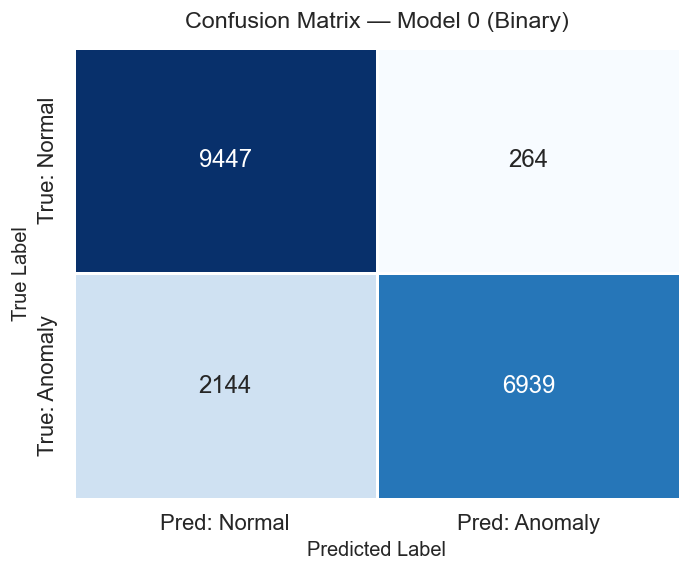

Interpretation:
- True Positives (caught anomalies): 6939
- False Positives (false alarms): 264


In [5]:
y_pred_binary = model_binary.predict(X_test_binary_features)

print("Classification Report — Model 0 (Binary)")
print(classification_report(
    y_test_binary,
    y_pred_binary,
    target_names=["Normal", "Anomaly"],
    zero_division=0,
))

cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_binary,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred: Normal", "Pred: Anomaly"],
    yticklabels=["True: Normal", "True: Anomaly"],
    linewidths=0.8,
    linecolor="white",
)
ax.set_title("Confusion Matrix — Model 0 (Binary)", pad=12)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- True Positives (caught anomalies):", cm_binary[1, 1])
print("- False Positives (false alarms):", cm_binary[0, 1])

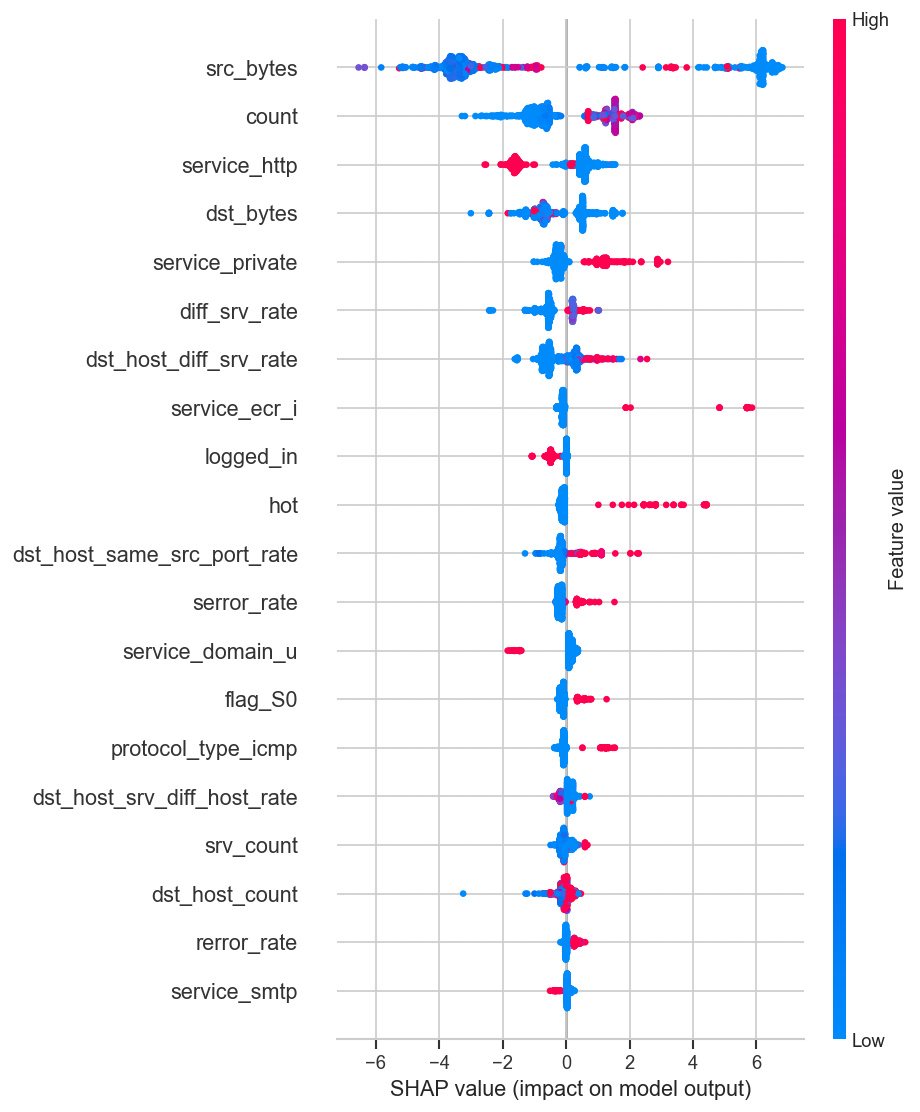

In [6]:
# SHAP explanation for Model 0 (global Normal vs. Anomaly drivers)
explainer_binary = shap.TreeExplainer(model_binary)

sample_size = min(1000, len(X_test_binary_features))
X_test_binary_sample = X_test_binary_features.sample(n=sample_size, random_state=42)

shap_values_binary = explainer_binary.shap_values(X_test_binary_sample)

# For binary LightGBM, SHAP may return either a single array or a list of two arrays.
if isinstance(shap_values_binary, list):
    shap_values_to_plot = shap_values_binary[1]
else:
    shap_values_to_plot = shap_values_binary

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_plot, X_test_binary_sample, show=True)

## 2 — Model 1: Specific Attack Classification

A LightGBM classifier trained to distinguish all individual attack types present in the NSL-KDD dataset.
`class_weight='balanced'` compensates for the severe class imbalance across rare attacks like *spy*, *perl*, and *loadmodule*.

In [7]:
model_specific = lgb.LGBMClassifier(
    objective="multiclass",
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_specific.fit(X_train, y_train_specific)
print(f"Model 1 trained — {model_specific.n_classes_} classes detected.")

Model 1 trained — 23 classes detected.


## 3 — Model 2: 5-Category Classification

A second LightGBM classifier that groups attacks into five high-level categories:
**Normal, DoS, Probe, R2L, U2R**.

Rows with `mapped_class_encoded == -1` (attack types in the test set that have no category mapping) are excluded from both training and evaluation.

In [8]:
model_mapped = lgb.LGBMClassifier(
    objective="multiclass",
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_mapped.fit(X_train_mapped, y_train_mapped)
print(f"Model 2 trained — {model_mapped.n_classes_} categories: {CATEGORY_LIST}")

Model 2 trained — 5 categories: ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']


## Model 2.1: The Maximized 5-Category Model

This upgraded variant targets better recall and F1 for R2L and U2R by combining SMOTE-NC resampling, heavier class penalties, and probability-threshold overrides at inference time.

In [9]:
from imblearn.over_sampling import SMOTENC

cat_feat_idx = [
    idx for idx, col in enumerate(X_train_mapped.columns)
    if any(prefix in col for prefix in ("protocol_type_", "service_", "flag_"))
]

if not cat_feat_idx:
    raise ValueError("No categorical OHE feature indices were detected for SMOTENC.")

print(f"Detected {len(cat_feat_idx)} categorical OHE feature indices for SMOTENC.")

smote_nc = SMOTENC(categorical_features=cat_feat_idx, random_state=42)
X_train_smote, y_train_smote = smote_nc.fit_resample(X_train_mapped, y_train_mapped)

class_dist_smote = pd.Series(y_train_smote).value_counts().sort_index()
print("\nPost-SMOTENC class distribution:")
for class_id, count in class_dist_smote.items():
    print(f"  {CATEGORY_NAMES[int(class_id)]} ({int(class_id)}): {count:,}")

Detected 84 categorical OHE feature indices for SMOTENC.

Post-SMOTENC class distribution:
  Normal (0): 67,342
  DoS (1): 67,342
  Probe (2): 67,342
  R2L (3): 67,342
  U2R (4): 67,342


In [10]:
model_mapped_max = lgb.LGBMClassifier(
    objective="multiclass",
    class_weight={0: 1, 1: 1, 2: 2, 3: 10, 4: 20},
    n_jobs=-1,
    verbose=-1,
    random_state=42,
)

model_mapped_max.fit(X_train_smote, y_train_smote)
print(f"Model 2.1 trained — {model_mapped_max.n_classes_} categories: {CATEGORY_LIST}")

Model 2.1 trained — 5 categories: ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']


In [11]:
proba_m21 = model_mapped_max.predict_proba(X_test_mapped)

if not np.array_equal(np.sort(model_mapped_max.classes_), np.array([0, 1, 2, 3, 4])):
    raise ValueError(f"Unexpected class order: {model_mapped_max.classes_}")

y_pred_m21 = np.argmax(proba_m21, axis=1)

# Threshold overrides to improve recall for stealthy classes.
# Use deterministic precedence for overlap: assign class with higher probability.
r2l_mask = proba_m21[:, 3] > 0.15
u2r_mask = proba_m21[:, 4] > 0.15
both_mask = r2l_mask & u2r_mask
only_r2l = r2l_mask & ~u2r_mask
only_u2r = u2r_mask & ~r2l_mask

y_pred_m21[only_r2l] = 3
y_pred_m21[only_u2r] = 4
y_pred_m21[both_mask] = np.where(
    proba_m21[both_mask, 4] >= proba_m21[both_mask, 3],
    4,
    3,
)

MODEL 2.1 — Maximized 5-Category Classification Report
              precision    recall  f1-score   support

      Normal       0.90      0.97      0.93      9711
         DoS       0.99      0.99      0.99      5741
       Probe       0.82      1.00      0.90      1106
         R2L       0.99      0.40      0.57      2199
         U2R       0.05      0.43      0.09        37

    accuracy                           0.91     18794
   macro avg       0.75      0.76      0.70     18794
weighted avg       0.93      0.91      0.90     18794



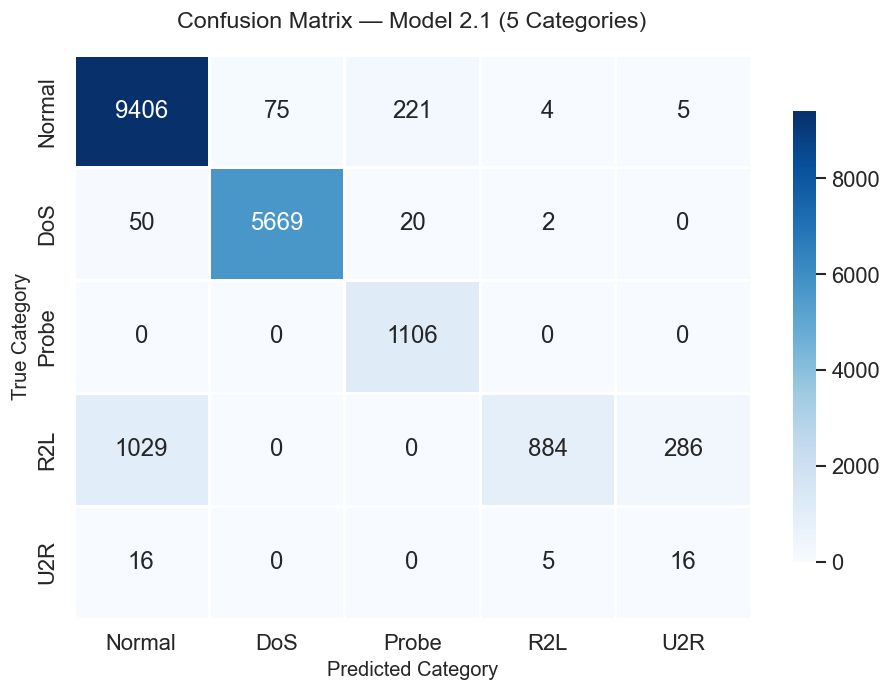

In [12]:
cm_m21 = confusion_matrix(y_test_mapped, y_pred_m21)

print("=" * 72)
print("MODEL 2.1 — Maximized 5-Category Classification Report")
print("=" * 72)
print(classification_report(
    y_test_mapped,
    y_pred_m21,
    target_names=CATEGORY_LIST,
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_m21,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORY_LIST,
    yticklabels=CATEGORY_LIST,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Confusion Matrix — Model 2.1 (5 Categories)", pad=16)
ax.set_xlabel("Predicted Category")
ax.set_ylabel("True Category")
plt.tight_layout()
plt.show()

## 4 — Model Evaluation

### 4.1 Model 1 — Specific Attack Classification Report

In [13]:
y_pred_specific = model_specific.predict(X_test)

print("=" * 72)
print("MODEL 1 — Specific Attack Classification Report")
print("=" * 72)
print(classification_report(y_test_specific, y_pred_specific, zero_division=0))

MODEL 1 — Specific Attack Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.48      0.38      0.43       359
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00         3
           4       1.00      0.03      0.06      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.99      0.99      0.99       141
           8       1.00      1.00      1.00         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94      1.00      0.97      4657
          15       0.43      1.00      0.61        73
          16       0.65      0.97

### 4.2 Model 1 — Confusion Matrix

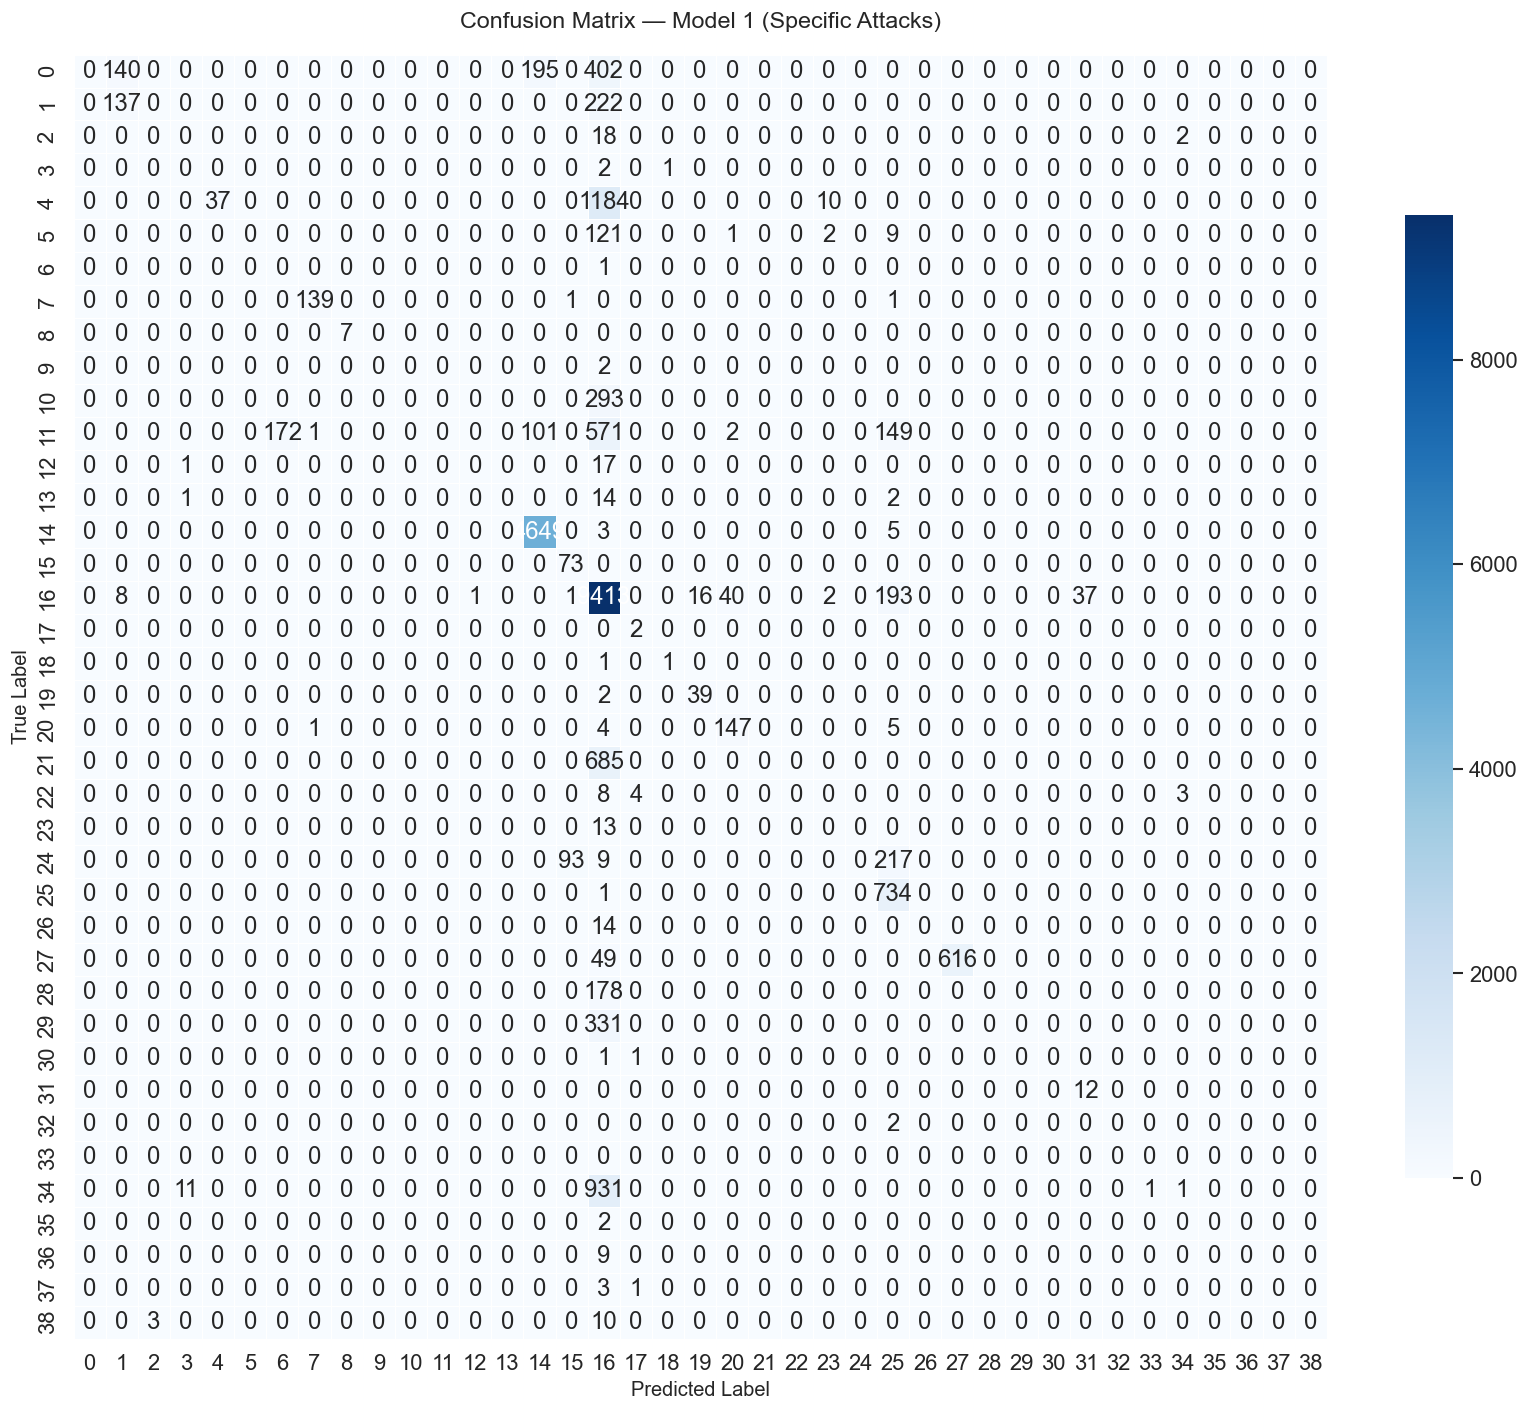

In [14]:
cm_specific = confusion_matrix(y_test_specific, y_pred_specific)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_specific,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Confusion Matrix — Model 1 (Specific Attacks)", pad=16)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

### 4.3 Model 2 — 5-Category Classification Report

In [15]:
y_pred_mapped = model_mapped.predict(X_test_mapped)

print("=" * 72)
print("MODEL 2 — 5-Category Classification Report")
print("=" * 72)
print(classification_report(
    y_test_mapped,
    y_pred_mapped,
    target_names=CATEGORY_LIST,
    zero_division=0,
))

MODEL 2 — 5-Category Classification Report
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.88      9711
         DoS       0.99      0.96      0.97      5741
       Probe       0.81      1.00      0.90      1106
         R2L       0.99      0.13      0.23      2199
         U2R       0.62      0.22      0.32        37

    accuracy                           0.87     18794
   macro avg       0.84      0.66      0.66     18794
weighted avg       0.89      0.87      0.84     18794



### 4.4 Model 2 — Confusion Matrix

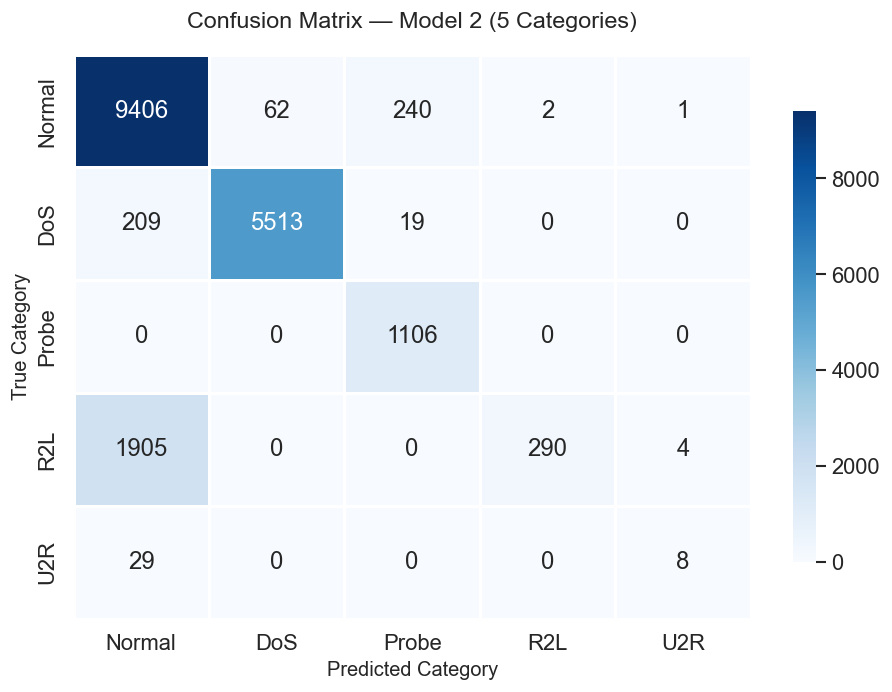

In [16]:
cm_mapped = confusion_matrix(y_test_mapped, y_pred_mapped)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_mapped,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORY_LIST,
    yticklabels=CATEGORY_LIST,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Confusion Matrix — Model 2 (5 Categories)", pad=16)
ax.set_xlabel("Predicted Category")
ax.set_ylabel("True Category")
plt.tight_layout()
plt.show()

## 5 — Explainable AI with SHAP

SHAP (SHapley Additive exPlanations) assigns each feature an importance value for every prediction.
We use `TreeExplainer` — optimised for tree-based models like LightGBM — on **Model 2** (the 5-category classifier) to understand which network-traffic features drive each category's predictions.

A random sample of **1 000** test instances is used to keep computation time manageable.

In [17]:
SHAP_SAMPLE_SIZE = 1000

np.random.seed(42)
sample_idx = np.random.choice(
    X_test_mapped.shape[0], size=SHAP_SAMPLE_SIZE, replace=False
)
X_sample = X_test_mapped.iloc[sample_idx]

explainer = shap.TreeExplainer(model_mapped_max)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {SHAP_SAMPLE_SIZE} samples.")
print(f"Shape per class: {shap_values[0].shape}  |  Number of classes: {len(shap_values)}")

SHAP values computed for 1000 samples.
Shape per class: (109, 5)  |  Number of classes: 1000


### 5.1 SHAP Summary Plot

Each row is a feature; each dot is a single test sample. The colour shows the feature value (red = high, blue = low) and the horizontal position shows the SHAP impact on the model output for each class.

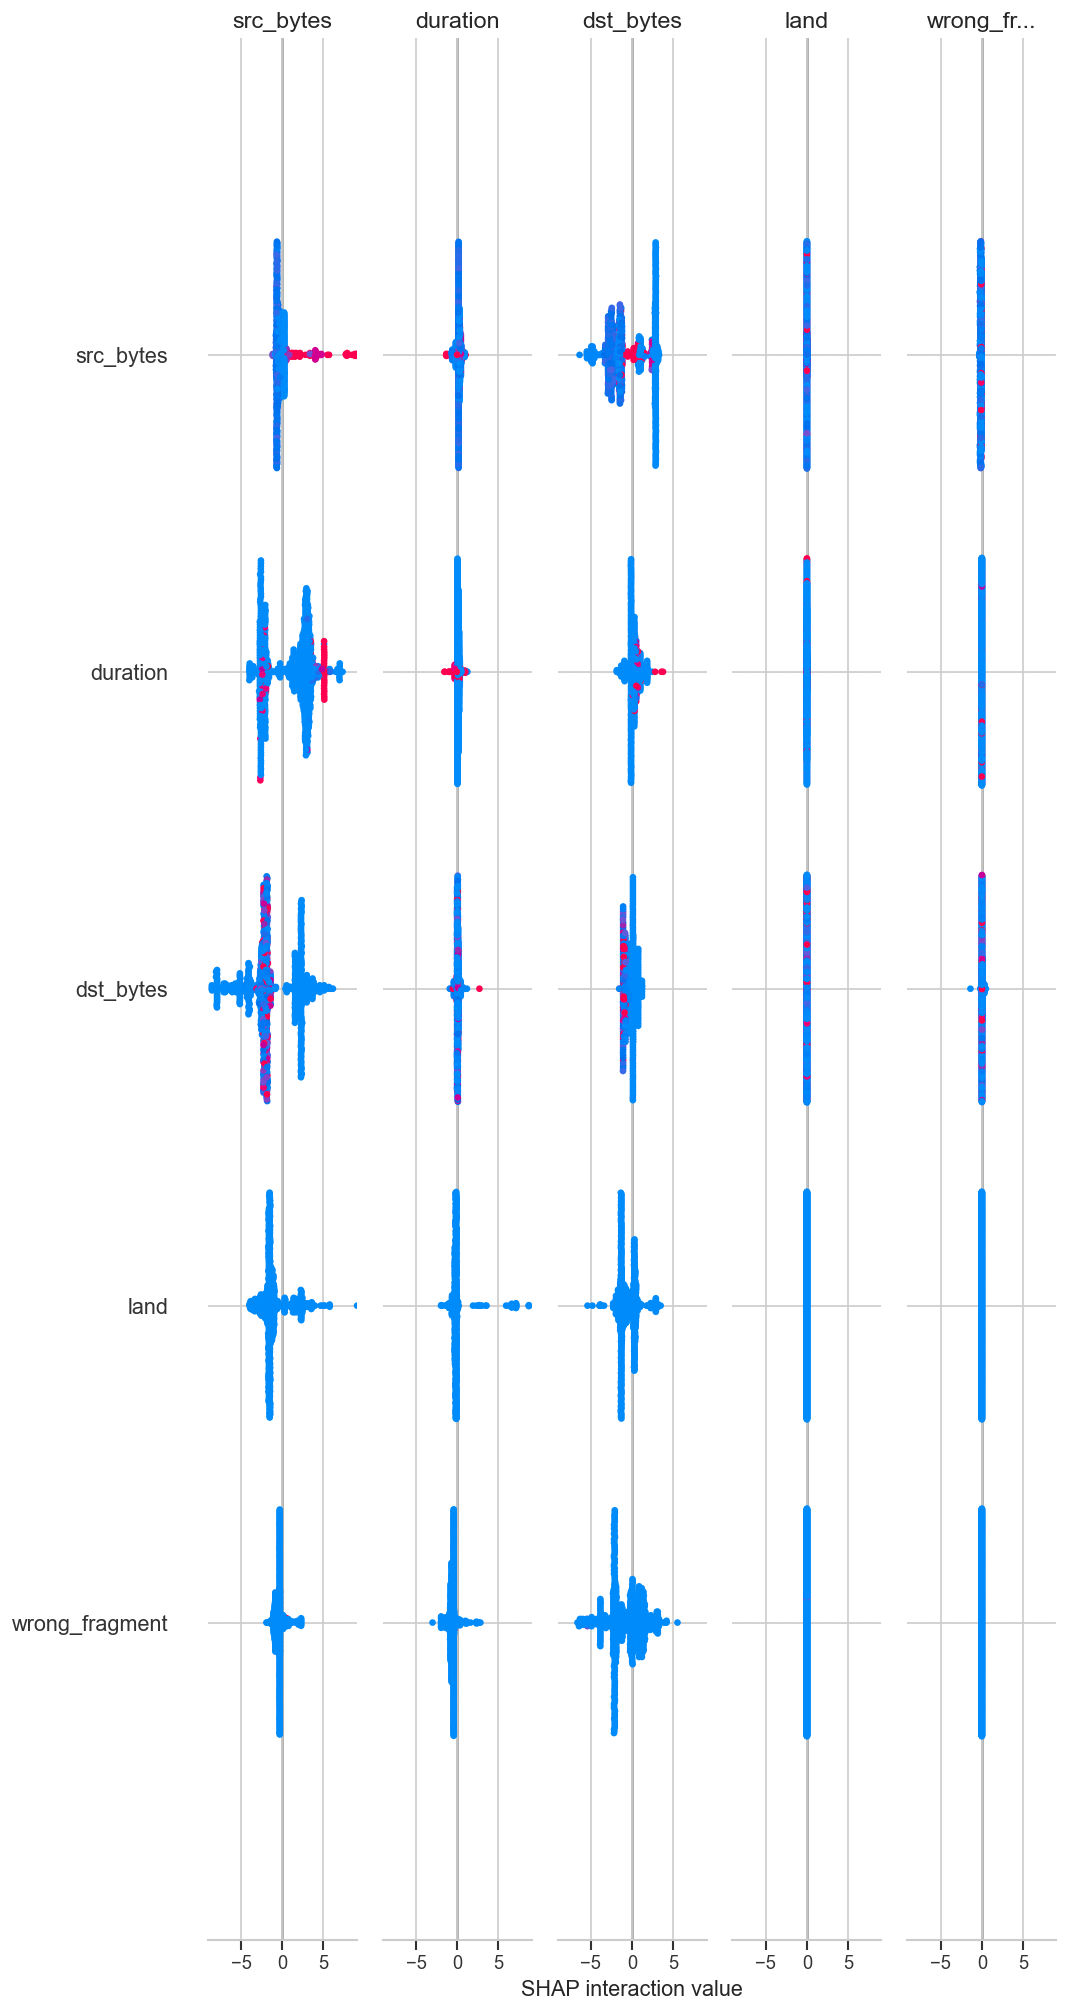

In [18]:
shap.summary_plot(
    shap_values,
    X_sample,
    class_names=CATEGORY_LIST,
    show=False,
    max_display=20,
)
plt.tight_layout()
plt.show()